<center><img src="images/clothing.jpg"></center>

Welcome to the world of e-commerce, where customer feedback is a goldmine of insights! In this project, you'll dive into the Women's Clothing E-Commerce Reviews dataset, focusing on the 'Review Text' column filled with direct customer opinions.

Your mission is to use text embeddings and Python to analyze these reviews, uncover underlying themes, and understand customer sentiments. This analysis will help improve customer service and product offerings.

## The Data

You will be working with a dataset specifically focusing on customer reviews. Below is the data dictionary for the relevant field:

## womens_clothing_e-commerce_reviews.csv

| Column        | Description                           |
|---------------|---------------------------------------|
| `'Review Text'` | Textual feedback provided by customers about their shopping experience and product quality. |

Armed with access to powerful embedding API services, you will process the reviews, extract meaningful insights, and present your findings.

Let's get started!

## Install useful libraries

In [8]:
# Run this cell to install ChromaDB if desired
try:
    assert version('chromadb') == '0.4.17'
except:
    !pip install chromadb==0.4.17
try:
    assert version('pysqlite3') == '0.5.2'
except:
    !pip install pysqlite3-binary==0.5.2
__import__('pysqlite3')
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')
import chromadb

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


## Load the dataset
Load data and perform basic data checks to ensure you are using relevant data for the analysis

In [9]:
# Load the dataset
import pandas as pd
reviews = pd.read_csv("womens_clothing_e-commerce_reviews.csv")

# Display the first few entries
reviews.head()

,Review ID,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


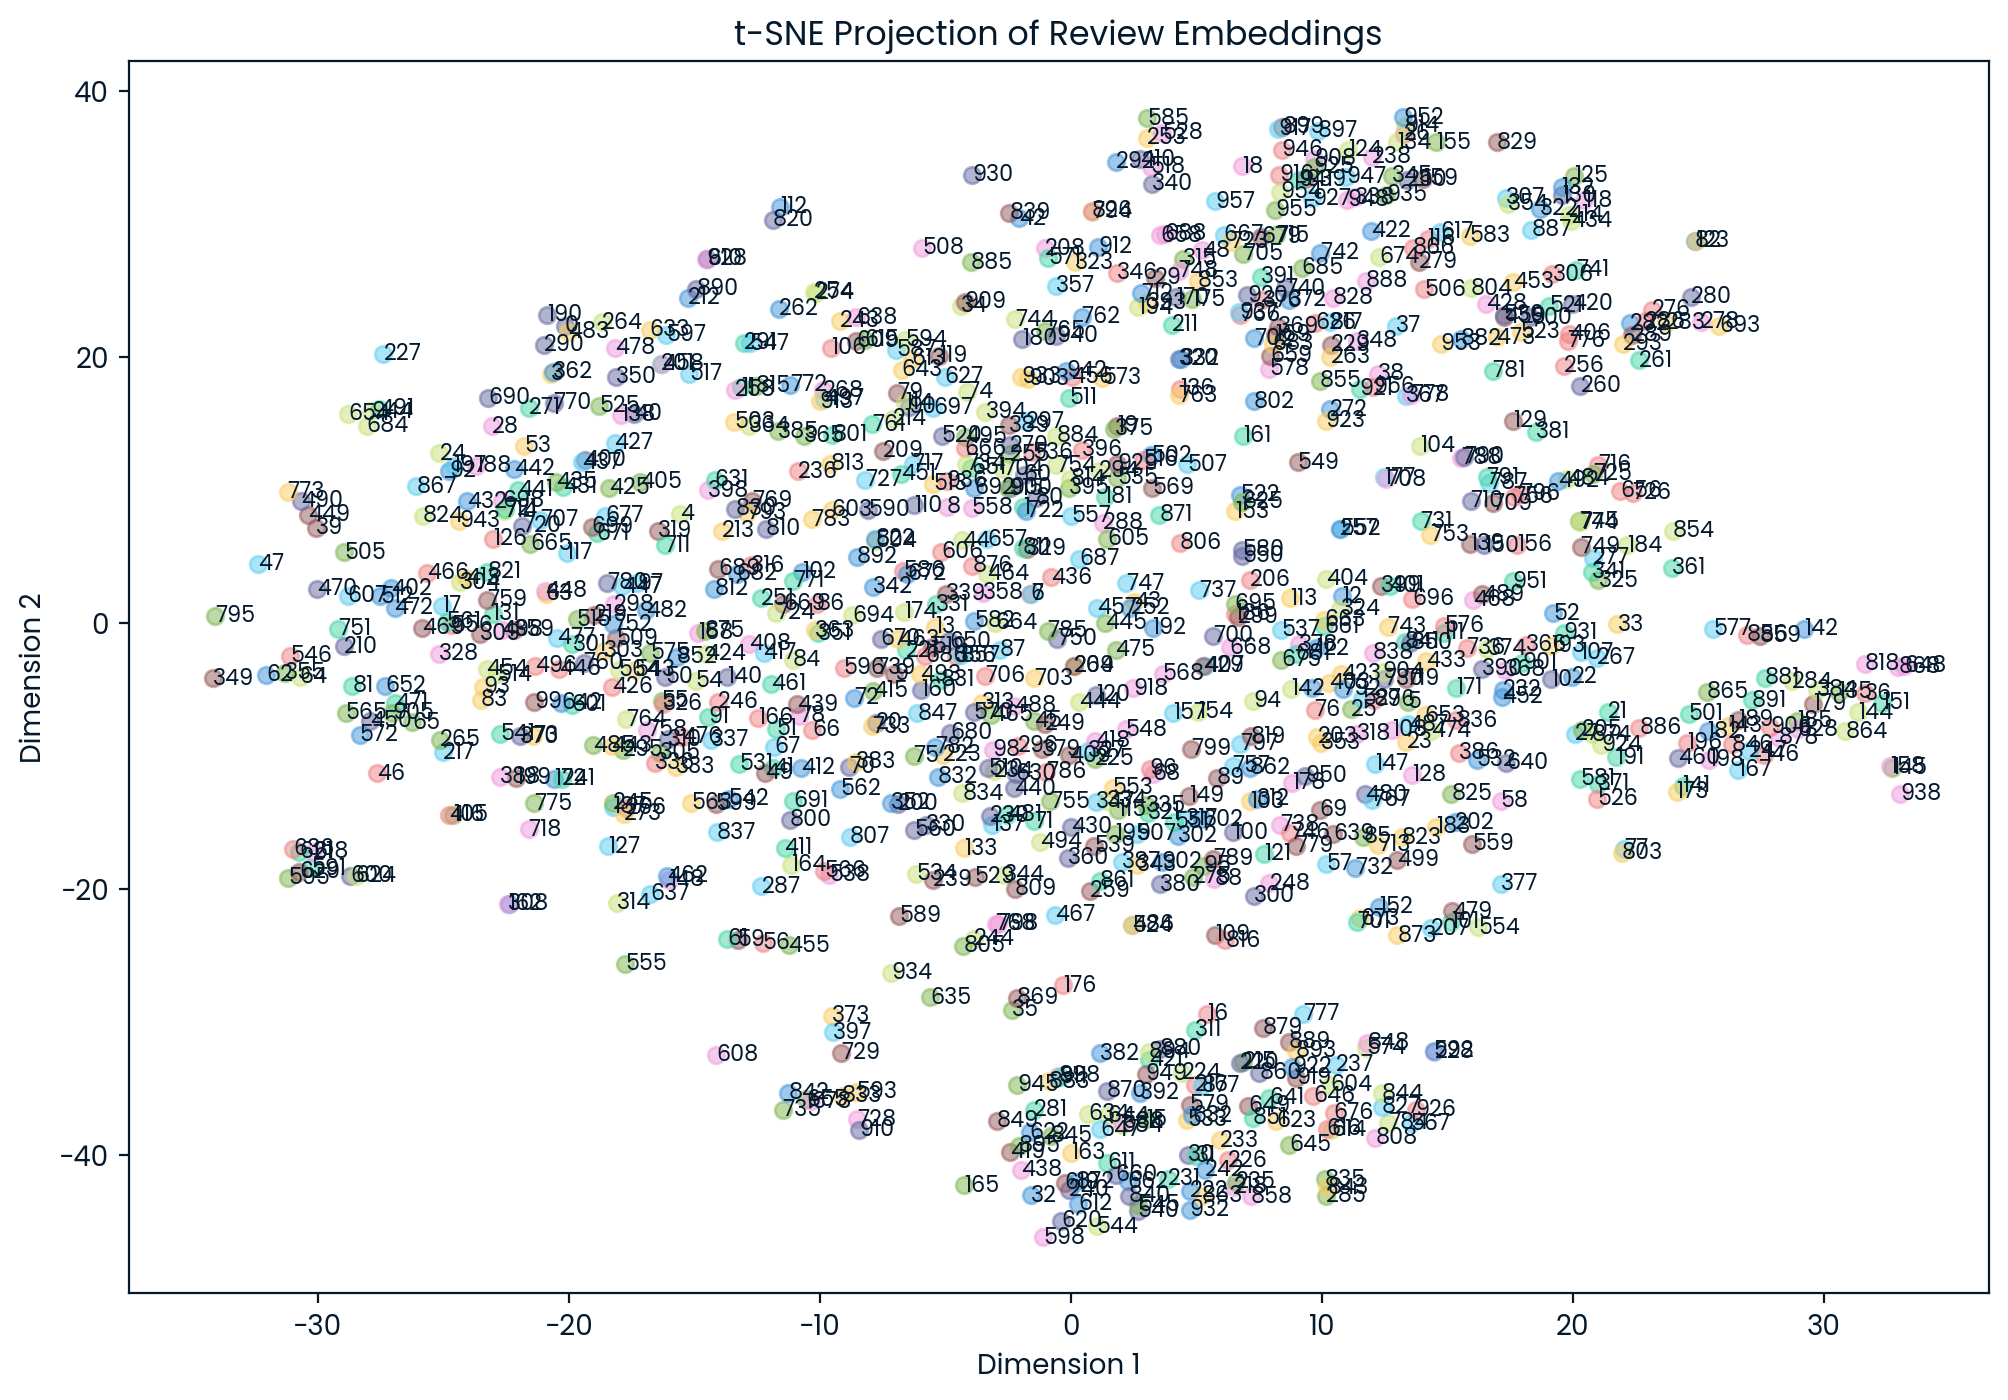

['Absolutely wonderful - silky and sexy and comfortable', 'Very comfortable and versatile. got lots of compliments.', 'This is a very comfortable and sexy sleep dress, the way it drapes. i can see that the type of fabric is not suitable for out and about activities and can catch on snags, etc. very easily. once i relegated it to the nightgown category it became my favorite item to wear and lounge in.']


In [10]:
# Start coding here
# Use as many cells as you need.
# Import dependencies
import os
import openai
import chromadb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.spatial import distance
from sklearn.manifold import TSNE
from chromadb.utils.embedding_functions import OpenAIEmbeddingFunction

# Configure embedding model
EMBED_MODEL = "text-embedding-3-small"

# Read review dataset
df = pd.read_csv("womens_clothing_e-commerce_reviews.csv")
texts = df["Review Text"].dropna()

# Generate embeddings in a single request
openai_client = openai.OpenAI()

embedding_response = openai_client.embeddings.create(
    input=texts.tolist(),
    model=EMBED_MODEL
).model_dump()

review_vectors = [
    item["embedding"]
    for item in embedding_response["data"]
]

# Reduce embedding dimensions with t-SNE
def compute_tsne(vectors):
    reducer = TSNE(
        n_components=2,
        random_state=0
    )
    return reducer.fit_transform(vectors)

tsne_vectors = compute_tsne(np.array(review_vectors))

# Visualize reduced embeddings
def visualize_tsne(points):
    plt.figure(figsize=(12, 8))

    for idx, coords in enumerate(points):
        plt.scatter(coords[0], coords[1], alpha=0.5)
        plt.text(
            coords[0],
            coords[1],
            str(idx),
            fontsize=8,
            verticalalignment="center"
        )

    plt.title("t-SNE Projection of Review Embeddings")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.show()

visualize_tsne(tsne_vectors)

# Define semantic categories
topics = ["Quality", "Fit", "Style", "Comfort"]

# Create category embeddings
topic_response = openai_client.embeddings.create(
    input=topics,
    model=EMBED_MODEL
).model_dump()

topic_vectors = [
    entry["embedding"]
    for entry in topic_response["data"]
]

# Assign category based on cosine similarity
def classify_review(vector, topic_vectors):
    scores = [
        {
            "distance": distance.cosine(vector, topic_vec),
            "index": idx
        }
        for idx, topic_vec in enumerate(topic_vectors)
    ]

    best_match = min(scores, key=lambda x: x["distance"])

    return topics[best_match["index"]]

# Predict categories for all reviews
assigned_topics = [
    classify_review(vector, topic_vectors)
    for vector in review_vectors
]

# Initialize Chroma persistent client
vector_client = chromadb.PersistentClient()

# Create embedding collection
review_collection = vector_client.create_collection(
    name="review_embeddings",
    embedding_function=OpenAIEmbeddingFunction(
        model_name=EMBED_MODEL,
        api_key=os.environ["OPENAI_API_KEY"]
    )
)

# Store review documents in vector DB
review_collection.add(
    documents=texts.tolist(),
    ids=[str(i) for i in range(len(texts))]
)

# Retrieve similar reviews from vector DB
def search_similar_reviews(query, collection, top_k=3):
    stored_collection = vector_client.get_collection(
        name="review_embeddings",
        embedding_function=OpenAIEmbeddingFunction(
            model_name=EMBED_MODEL,
            api_key=os.environ["OPENAI_API_KEY"]
        )
    )

    search_results = stored_collection.query(
        query_texts=[query],
        n_results=top_k
    )

    return search_results

# Example semantic similarity search
sample_review = "Absolutely wonderful - silky and sexy and comfortable"

similar_reviews = search_similar_reviews(
    sample_review,
    review_collection,
    3
)["documents"][0]

print(similar_reviews)

# Remove collection after execution
vector_client.delete_collection(name="review_embeddings")